2026-08-30 20:44:32.893 | INFO     | __main__:node_a:16 - cur_step: 1
2026-08-30 20:44:32.896 | INFO     | __main__:node_b:21 - cur_step: 2
2026-08-30 20:44:32.902 | INFO     | __main__:node_c:26 - cur_step: 2
2026-08-30 20:44:32.907 | INFO     | __main__:node_d:31 - cur_step: 3
2026-08-30 20:44:32.908 | INFO     | __main__:node_e:36 - cur_step: 4


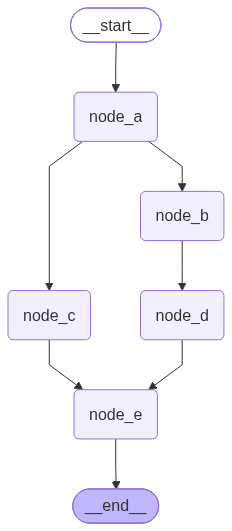

In [4]:
from langgraph.graph import StateGraph, START, END
from loguru import logger
from typing import TypedDict
from IPython.display import display

from langchain_core.runnables import RunnableConfig

from main import builder


class EmptyState(TypedDict):
    pass

def node_a(State: EmptyState, config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"cur_step: {cur_step}")
    return {}

def node_b(State: EmptyState, config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"cur_step: {cur_step}")
    return {}

def node_c(State: EmptyState, config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"cur_step: {cur_step}")
    return {}

def node_d(State: EmptyState, config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"cur_step: {cur_step}")
    return {}

def node_e(State: EmptyState, config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"cur_step: {cur_step}")
    return {}


builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_e", node_e)
builder.add_node("node_d", node_d)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")
# builder.add_edge("node_c", "node_e") #或执行
# builder.add_edge("node_d", "node_e")
builder.add_edge(["node_c", "node_d"], "node_e") # 与执行

builder.add_edge("node_e", END)

graph = builder.compile()
graph.invoke({})
display(graph)



